In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import ListedColormap
import glasbey
import netCDF4
import matplotlib
from shapely.geometry import Point

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
from uncertainty_experiments.uncertainty_metrics import compute_uncertainty_metrics
from visualisation.plotting import plot_sankey

# Longhurst provinces

Flanders Marine Institute (2009). Longhurst Provinces. Available online at https://www.marineregions.org/. Consulted on 2023-11-28.

https://www.marineregions.org/sources.php#longhurst

In [2]:
longhurst = gpd.read_file("../../data/province_shapes/longhurst_v4_2010/Longhurst_world_v4_2010.shp")

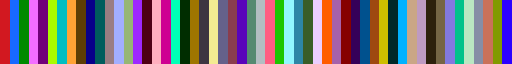

In [3]:
# Define color map and ranges
unique_labels = np.sort(longhurst.ProvCode.unique())

colors = glasbey.create_palette(palette_size=len(unique_labels))
cm = ListedColormap(colors)  

cm

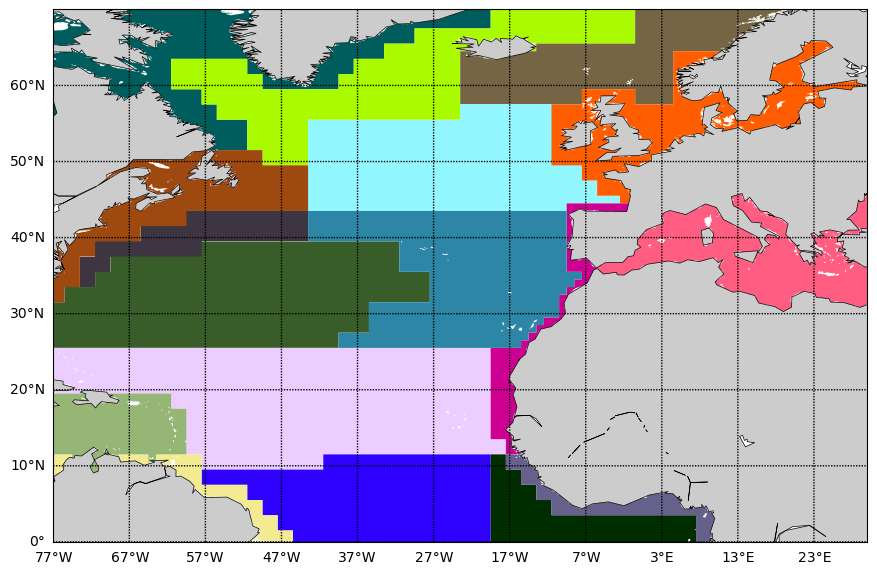

In [4]:
# Defining our area of interest
lat_min = 0
lat_max = 70

lon_min = -77
lon_max = 30

# Plot settings
factor = 12
mymap = Basemap(llcrnrlon=lon_min, llcrnrlat=lat_min, urcrnrlon=lon_max, urcrnrlat=lat_max)
plt.rcParams["figure.figsize"] = ((lon_max - lon_min)/factor, (lat_max - lat_min)/factor)

# Plot
longhurst.plot("ProvCode", cmap=cm, vmin=0, vmax=len(unique_labels))
mymap.drawcoastlines(linewidth=0.5)
mymap.fillcontinents()
mymap.drawparallels(np.arange(int(lat_min),int(lat_max), 10),labels=[1,0,0,0])
mymap.drawmeridians(np.arange(int(lon_min),int(lon_max), 10),labels=[0,0,0,1])
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.tight_layout()
# plt.savefig(f"{config.output_dir_plots}longhurst_surface.png")
plt.savefig(f"{config.output_dir_plots_high_res}longhurst_surface.png", dpi=1000)
plt.show()

<Axes: >

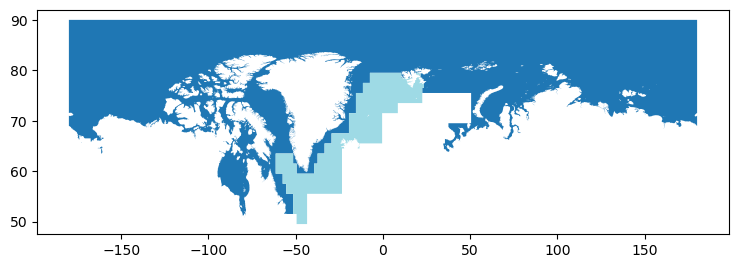

In [5]:
longhurst[longhurst.ProvCode.isin(["ARCT",  "BPLR",# "SARC", 
                                   # "NADR", "GFST", "NASW", 
                                   # "CARB", "NATR",
                                   # "WTRA", "ETRA", "NWCS", "MEDI", "NASE", 
                                  ])].plot(cmap="tab20")

# Overlay our regions with Longhurst's provinces

In [6]:
# Load our regions
my_regions = netCDF4.Dataset(f"{config.output_dir}cluster_set.nc")

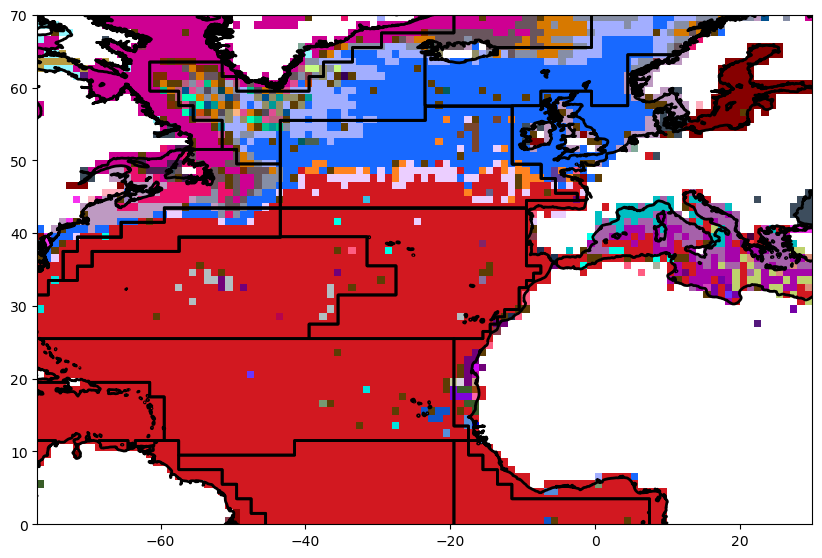

In [7]:
# Plot our area of interest
depth = 0.0
hex_colors = my_regions["color"][0, :, :] 
rgb = np.array([[matplotlib.colors.to_rgb(color) if type(color) == str and color is not None and color != "" else np.array([1, 1, 1]) for color in row] for row in hex_colors])
    
# Defining out area
lat_min = 0
lat_max = 70

lon_min = -77
lon_max = 30

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(rgb, extent=[lon_min, lon_max, lat_min, lat_max], origin='lower')
longhurst.plot("ProvCode", ax=ax, edgecolor="black", facecolor="none", linewidth=2)  

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

plt.show()

# Compute overlap scores

In [8]:
# Load our regions and filter for surface
df = pd.read_csv(f"{config.output_dir}cluster_set.csv")
df_surface = df[df["LEV_M"] == 0].copy()

In [9]:
# Map Longhurst provinces to our grid
# Create GeoDataFrame of surface points
geometry = [Point(xy) for xy in zip(df_surface["LONGITUDE"], df_surface["LATITUDE"])]
gdf_surface = gpd.GeoDataFrame(df_surface, geometry=geometry, crs=longhurst.crs)

# Spatially join points with Longhurst polygons
joined = gpd.sjoin(gdf_surface, longhurst[["ProvCode", "geometry"]], how="left", predicate="within")
df_surface["longhurst_label"] = joined["ProvCode"].values

# Drop cells that did not get assigned a Longhurst label
df_surface = df_surface.dropna()

In [10]:
# Compute overlap metrics between the two cluster sets (our surface and Longhurst)
clustering_a = df_surface[["LATITUDE", "LONGITUDE", "LEV_M", "label"]].copy()
clustering_b = df_surface[["LATITUDE", "LONGITUDE", "LEV_M", "longhurst_label"]].copy()
clustering_b.loc[:, "longhurst_cats"] = pd.Categorical(df_surface["longhurst_label"]).codes

compute_uncertainty_metrics(clustering_a, clustering_b, label_a="label", label_b="longhurst_cats")

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\uncertainty_experiments\uncertainty_metrics.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 6  6  6 ... 15 15 15]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  clustering_b.loc[:, label_b] = clustering_b.loc[:, label_b].astype(int)


,overlap_ab,overlap_ba,overlap,f_accuracy_ab,f_accuracy_ba,f_accuracy,mutual_information,variation_of_information,normalized_mutual_information,adjusted_rand_score
0,0.393192,0.723107,0.55815,0.3741,0.331537,0.352818,0.961967,2.551593,0.429879,0.156402


Our results show that the new surface clustering shares some structural similarity with the Longhurst provinces (NMI = 0.430; WOA = 0.393), but the relatively low ARI (0.156) highlights differences in spatial boundaries and label assignments. This suggests that while the clustering captures broad-scale biogeographic patterns, it also reveals finer or alternative subdivisions of the ocean surface not present in Longhurst’s static classification. The moderate NMI supports partial thematic consistency, while the overlay accuracy confirms that several clusters predominantly overlap with individual provinces.

To assess the correspondence between our custom-defined oceanic clusters and the established Longhurst biogeographical provinces, we computed a suite of overlap and similarity metrics. The results indicate a moderate degree of spatial overlap, with 39.3% of our clusters intersecting Longhurst regions (overlap_ab) and 72.3% of Longhurst provinces overlapping with our clusters (overlap_ba). However, structural similarity between the two cluster sets remains limited, as reflected by a normalized mutual information (NMI) of 0.43 and an adjusted Rand index (ARI) of 0.16. These values suggest that while there is partial alignment—particularly in terms of spatial coverage—the underlying partitioning strategies differ substantially, likely due to variations in methodological approach and clustering objectives.

In [54]:
# Sankey plot
s = plot_sankey(df_surface, source_col="label", target_col="longhurst_label", color_col="uncertainty", color_palette="Blues_9", figsize_px=(827*2, 1169*2), save_as=f"{config.output_dir_plots_high_res}/sankey_longhurst.png")

# Save as SVG (convert to PDF externally)
s.auto_save_svg(f"{config.output_dir_plots_high_res}/sankey_longhurst.svg")

SankeyWidget(groups=[{'id': 'Labels', 'type': 'process', 'title': '', 'nodes': ['Labels^0', 'Labels^1', 'Label…